<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Age                   500000 non-null  int64  
 1   AnnualIncome          500000 non-null  float64
 2   NumberOfPurchases     500000 non-null  int64  
 3   TimeSpentOnWebsite    500000 non-null  float64
 4   CustomerTenureYears   500000 non-null  float64
 5   LastPurchaseDaysAgo   500000 non-null  int64  
 6   Gender                500000 non-null  object 
 7   ProductCategory       500000 non-null  object 
 8   PreferredDevice       500000 non-null  object 
 9   Region                500000 non-null  object 
 10  ReferralSource        500000 non-null  object 
 11  CustomerSegment       500000 non-null  object 
 12  LoyaltyProgram        500000 non-null  int64  
 13  DiscountsAvailed      500000 non-null  int64  
 14  SessionCount          500000 non-null  int64  
 15  

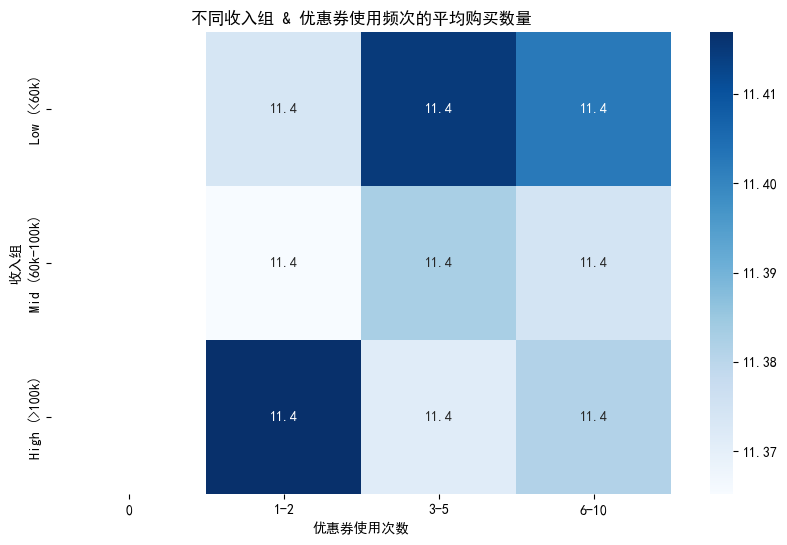

count    500000.000000
mean         11.387584
std           6.000702
min          -1.000000
25%           6.000000
50%          12.000000
75%          16.000000
max          28.000000
Name: NumberOfPurchases, dtype: float64
                            OLS Regression Results                            
Dep. Variable:      NumberOfPurchases   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.01541
Date:                Sun, 05 Apr 2026   Prob (F-statistic):              0.901
Time:                        09:52:57   Log-Likelihood:            -1.6054e+06
No. Observations:              500000   AIC:                         3.211e+06
Df Residuals:                  499998   BIC:                         3.211e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                            

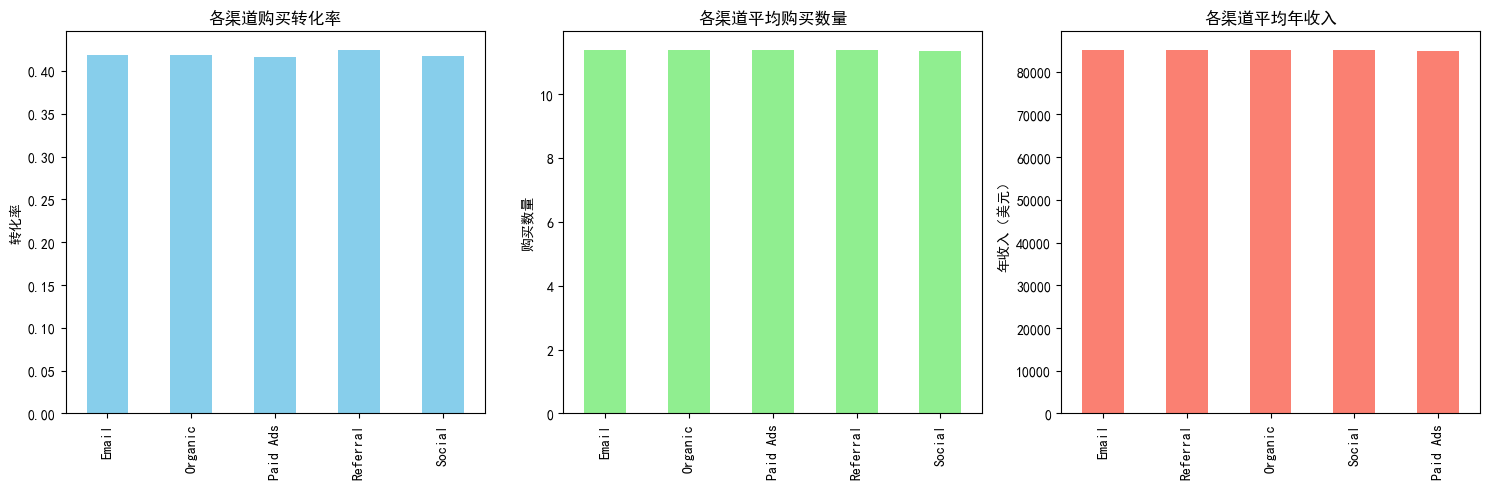

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']   # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False     # 用来正常显示负号


# 读取数据
df = pd.read_csv(r"C:\Users\chen\Downloads\customerData_500k.csv")

# 查看数据基本信息（行数、列数、类型等）
print(df.info())
# 查看各列缺失值数量及比例
print(df.isnull().sum())
print(df.isnull().mean() * 100)
# 数据形状
print(df.shape)
# 打印所有列的前几行（最大列数不限制）
with pd.option_context('display.max_columns', None):
    print(df.head())

# 优惠券使用次数的描述统计与频数分布
print(df['DiscountsAvailed'].describe())
print(df['DiscountsAvailed'].value_counts().head(10))

# 创建优惠券使用频次分组（用于热力图）
bins_coupon = [-0.1, 0, 2, 5, 11]   # 左闭右开，因为最大值10，所以上限设11
labels_coupon = ['0', '1-2', '3-5', '6-10']
df['coupon_group'] = pd.cut(df['DiscountsAvailed'], bins=bins_coupon, labels=labels_coupon, right=False)
print(df['coupon_group'].value_counts())

# 年收入的描述统计与分位数
print(df['AnnualIncome'].describe())
print(df['AnnualIncome'].quantile([0.33, 0.66]))

# 创建收入分组
bins_income = [0, 60000, 100000, np.inf]   # np.inf 表示无穷大，确保包含所有大于10万的收入
labels_income = ['Low (<60k)', 'Mid (60k-100k)', 'High (>100k)']
df['income_group'] = pd.cut(df['AnnualIncome'], bins=bins_income, labels=labels_income, right=False)
print(df['income_group'].value_counts())

# 绘制热力图：收入组 × 优惠券组 的平均购买数量
heatmap_data = df.groupby(['income_group', 'coupon_group'], observed=False)['NumberOfPurchases'].mean().unstack()
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Blues')
plt.title('不同收入组 & 优惠券使用频次的平均购买数量')
plt.xlabel('优惠券使用次数')
plt.ylabel('收入组')
plt.show()

# 查看购买数量的描述统计
print(df['NumberOfPurchases'].describe())

# 导入 statsmodels 用于回归分析
import statsmodels.api as sm

# 简单线性回归：优惠券次数 → 购买数量
X = df[['DiscountsAvailed']]
X = sm.add_constant(X)
y = df['NumberOfPurchases']
model = sm.OLS(y, X).fit()
print(model.summary())

# 多元回归：控制收入、年龄、网站停留时间
features = ['DiscountsAvailed', 'AnnualIncome', 'Age', 'TimeSpentOnWebsite']
X = df[features]
X = sm.add_constant(X)
y = df['NumberOfPurchases']
model = sm.OLS(y, X).fit()
print(model.summary())

# 分层回归：按收入组分别做简单回归，看效果是否因收入而异
for group in ['Low (<60k)', 'Mid (60k-100k)', 'High (>100k)']:
    subset = df[df['income_group'] == group]
    X = subset[['DiscountsAvailed']]
    X = sm.add_constant(X)
    y = subset['NumberOfPurchases']
    model = sm.OLS(y, X).fit()
    print(f"{group}: β1={model.params['DiscountsAvailed']:.4f}, p={model.pvalues['DiscountsAvailed']:.4f}")

# 打印各推荐渠道的用户数量分布
print(df['ReferralSource'].value_counts())

# 2. 计算各渠道的短期指标（转化率、平均购买数量）
channel_stats = df.groupby('ReferralSource').agg(
    用户数=('PurchaseStatus', 'count'),          # 统计每个渠道的用户总数
    购买转化率=('PurchaseStatus', 'mean'),       # 购买转化率 = 购买人数/总人数
    平均购买数量=('NumberOfPurchases', 'mean')   # 平均购买数量
).round(4)                                      # 结果保留四位小数
print("=== 各渠道短期指标 ===")
print(channel_stats)

# 计算各渠道用户的平均年收入，并降序排列（收入最高的渠道显示在前面）
channel_income = df.groupby('ReferralSource')['AnnualIncome'].mean().round(2).sort_values(ascending=False)
print("=== 各渠道平均年收入 ===")
print(channel_income)

# 导入单因素方差分析函数
from scipy.stats import f_oneway
# 准备数据：将每个渠道的 PurchaseStatus 值（0/1）放入一个列表
groups = [df[df['ReferralSource'] == ch]['PurchaseStatus'].values for ch in df['ReferralSource'].unique()]
# 执行方差分析，比较各渠道转化率是否有显著差异
f_stat, p_val = f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={p_val:.4f}")

# 创建三个并列的子图（一行三列），画布尺寸 15x5 英寸
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 子图1：各渠道购买转化率柱状图
channel_stats['购买转化率'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('各渠道购买转化率')
axes[0].set_ylabel('转化率')
axes[0].set_xlabel('')   # 隐藏 x 轴标题（保留刻度标签）

# 子图2：各渠道平均购买数量柱状图
channel_stats['平均购买数量'].plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('各渠道平均购买数量')
axes[1].set_ylabel('购买数量')
axes[1].set_xlabel('')   # 隐藏 x 轴标题

# 子图3：各渠道平均年收入柱状图
channel_income.plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('各渠道平均年收入')
axes[2].set_ylabel('年收入（美元）')
axes[2].set_xlabel('')   # 隐藏 x 轴标题

# 自动调整子图布局，防止重叠
plt.tight_layout()
# 显示图表
plt.show()